# Capstone Project: Fraud Detection in Mobile Financial Transactions

**Student:** Varad Sandeep Naik
**Project:** Develop a robust machine learning model to accurately predict fraudulent transactions.

---

## Project Goal
Build a production-ready model that classifies each mobile financial transaction as **fraud (1)** or **legitimate (0)**.

## Why we are doing this
Banks lose money to fraud. Flagging fraud before approval saves that money, so the model needs high recall with good precision.


## 1. Importing all the libraries we need

In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

import joblib

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Loading the dataset

In [ ]:
df = pd.read_csv("Fraud_Analysis_Dataset.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


## 3. Basic Data Understanding

In [ ]:
print("Shape of the dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of the dataset: (11142, 10)
Number of rows: 11142
Number of columns: 10


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  str    
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  str    
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  str    
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 870.6 KB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [ ]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [ ]:
print("Fraud value counts:")
print(df["isFraud"].value_counts())

fraud_percent = df["isFraud"].mean() * 100
print(f"\nPercentage of fraudulent transactions: {fraud_percent:.4f}%")
print("This is a very imbalanced dataset (very few frauds compared to legitimate ones).")

Fraud value counts:
isFraud
0    10000
1     1142
Name: count, dtype: int64

Percentage of fraudulent transactions: 10.2495%
This is a very imbalanced dataset (very few frauds compared to legitimate ones).


## 4. Exploratory Data Analysis (EDA) with Visualizations

/var/folders/p2/kg9y5ngj55q5tgbx8zzcl5kh0000gn/T/ipykernel_49753/2763963691.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="isFraud", data=df, palette=["#1f77b4", "#d62728"])


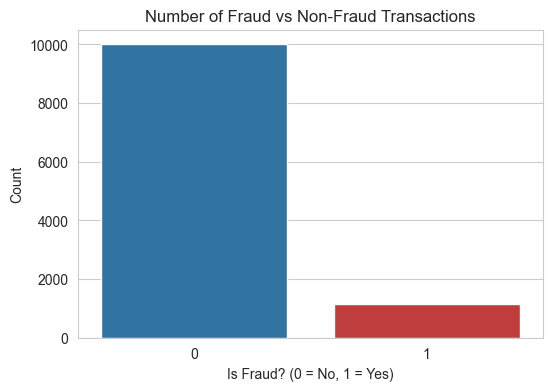

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="isFraud", data=df, palette=["#1f77b4", "#d62728"])
plt.title("Number of Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud? (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

/var/folders/p2/kg9y5ngj55q5tgbx8zzcl5kh0000gn/T/ipykernel_49753/1206107810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="type", data=df, order=df["type"].value_counts().index, palette="viridis")


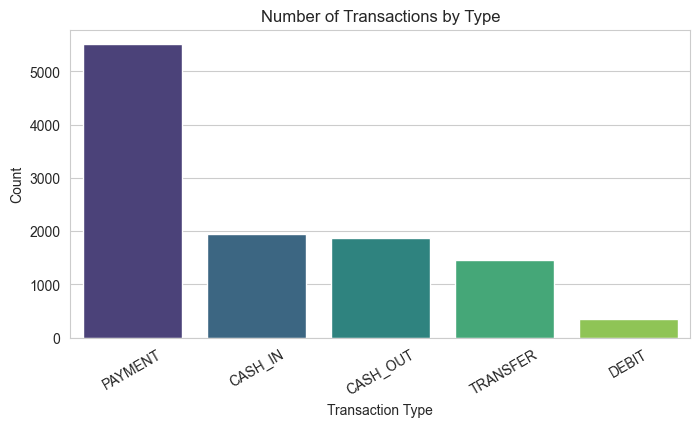

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x="type", data=df, order=df["type"].value_counts().index, palette="viridis")
plt.title("Number of Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

/var/folders/p2/kg9y5ngj55q5tgbx8zzcl5kh0000gn/T/ipykernel_49753/296633523.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values, palette="rocket")


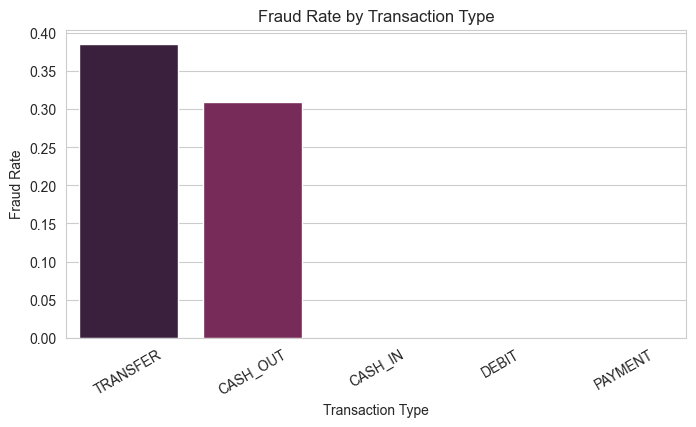


Fraud rate by transaction type:
type
TRANSFER    0.385246
CASH_OUT    0.308926
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [ ]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values, palette="rocket")
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30)
plt.show()

print("\nFraud rate by transaction type:")
print(fraud_by_type)

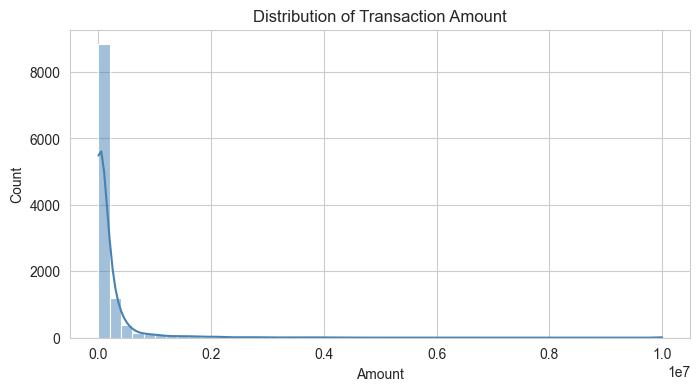

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["amount"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

/var/folders/p2/kg9y5ngj55q5tgbx8zzcl5kh0000gn/T/ipykernel_49753/1620924841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="isFraud", y="amount", data=df, palette=["#1f77b4", "#d62728"])


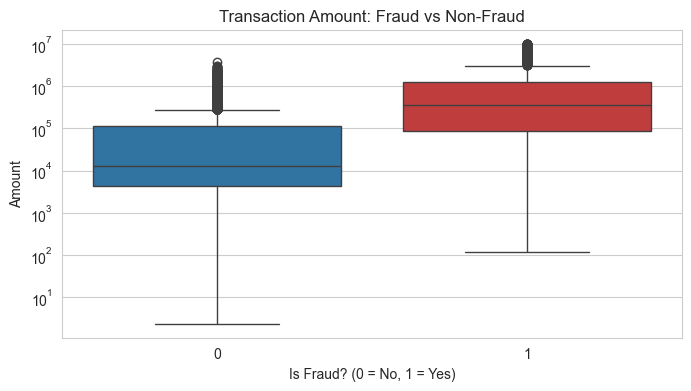

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="isFraud", y="amount", data=df, palette=["#1f77b4", "#d62728"])
plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud? (0 = No, 1 = Yes)")
plt.ylabel("Amount")
plt.yscale("log")
plt.show()

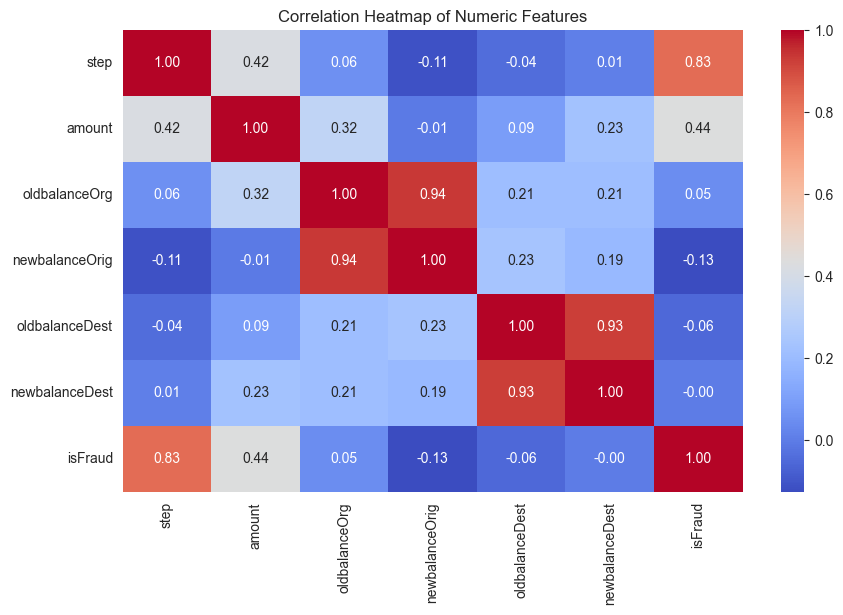

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## 5. Feature Engineering

1. Drop the name columns (they are just IDs).
2. One-hot encode the `type` column.
3. Create new features:
   - `balance_diff_orig` = old balance - new balance
   - `balance_diff_dest` = new balance - old balance
   - `is_zero_balance_orig` = whether the sender's account becomes empty
   - `is_zero_balance_dest` = whether the receiver's account was empty before


In [14]:
df_model = df.copy()
# I dropped the name columns because they are just customer IDs with no predictive signal.
df_model = df_model.drop(["nameOrig", "nameDest"], axis=1)
# I added balance_diff features to capture how much money moved, and zero-balance flags
# because wiping an account to zero is a common fraud pattern.
df_model["balance_diff_orig"] = df_model["oldbalanceOrg"] - df_model["newbalanceOrig"]
df_model["balance_diff_dest"] = df_model["newbalanceDest"] - df_model["oldbalanceDest"]
df_model["is_zero_balance_orig"] = (df_model["newbalanceOrig"] == 0).astype(int)
df_model["is_zero_balance_dest"] = (df_model["oldbalanceDest"] == 0).astype(int)

print("Shape after feature engineering:", df_model.shape)
df_model.head()


Shape after feature engineering: (11142, 12)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_orig,balance_diff_dest,is_zero_balance_orig,is_zero_balance_dest
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0,1,1
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0,1,0
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0,1,1
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0,1,0
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0,1,1


In [15]:
# I one-hot encoded the transaction type so the models could use it as numeric features.
df_model = pd.get_dummies(df_model, columns=["type"], drop_first=True)

print("Shape after one-hot encoding:", df_model.shape)
df_model.head()


Shape after one-hot encoding: (11142, 15)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_orig,balance_diff_dest,is_zero_balance_orig,is_zero_balance_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0,1,1,False,False,False,True
1,1,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0,1,0,True,False,False,False
2,1,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0,1,1,False,False,False,True
3,1,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0,1,0,True,False,False,False
4,1,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0,1,1,False,False,False,True


## 6. Train/Test Split

In [ ]:
X = df_model.drop("isFraud", axis=1)
y = df_model["isFraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11142, 14)
y shape: (11142,)


In [ ]:
# I stratified the split by the fraud label so train and test keep the same imbalance ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Fraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training set size: 8913
Testing set size: 2229
Fraud in training: 914
Fraud in testing: 228


## 7. Feature Scaling

In [ ]:
# I fit the scaler only on training data and applied it to both sets, to avoid leaking
# test information into the training step.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print("Example of scaled training values (first 3 rows, first 5 columns):")
print(X_train_scaled[:3, :5])

Scaling done.
Example of scaled training values (first 3 rows, first 5 columns):
[[-0.1066963  -0.26005254 -0.41015066 -0.37954282 -0.34178504]
 [-0.1066963   0.11509556 -0.42955247 -0.39313299  4.77239116]
 [-0.16867793 -0.27018323 -0.42955247 -0.39313299 -0.34178504]]


## 8. Model Building

Four classifiers are trained and compared:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting


In [ ]:
# I compared four classifiers with sensible defaults, then picked the best by F1 score.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
    }

    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")

print("\nAll models trained!")


Training Logistic Regression...
  Accuracy : 0.9892
  Precision: 0.9904
  Recall   : 0.9035
  F1 Score : 0.9450
  ROC-AUC  : 0.9940

Training Decision Tree...
  Accuracy : 0.9942
  Precision: 0.9778
  Recall   : 0.9649
  F1 Score : 0.9713
  ROC-AUC  : 0.9812

Training Random Forest...
  Accuracy : 0.9964
  Precision: 1.0000
  Recall   : 0.9649
  F1 Score : 0.9821
  ROC-AUC  : 0.9999

Training Gradient Boosting...
  Accuracy : 0.9964
  Precision: 0.9955
  Recall   : 0.9693
  F1 Score : 0.9822
  ROC-AUC  : 0.9991

All models trained!


## 9. Model Comparison and Visualization

### Key Findings
- Gradient Boosting achieved the highest F1 score (0.9822) and recall (0.9693).
- Random Forest reached the highest ROC-AUC (0.9999) with perfect precision (1.0000).
- All four models exceeded 0.98 accuracy; the dataset is easy to separate but imbalanced.
- Gradient Boosting is selected as the best model for the balance of precision and recall.


In [ ]:
summary = pd.DataFrame({
    name: {
        "Accuracy": results[name]["accuracy"],
        "Precision": results[name]["precision"],
        "Recall": results[name]["recall"],
        "F1 Score": results[name]["f1"],
        "ROC-AUC": results[name]["roc_auc"],
    }
    for name in results
}).T

summary = summary.sort_values("F1 Score", ascending=False)
print("Model Comparison Table (sorted by F1 Score):")
print(summary.round(4))

Model Comparison Table (sorted by F1 Score):
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Gradient Boosting      0.9964     0.9955  0.9693    0.9822   0.9991
Random Forest          0.9964     1.0000  0.9649    0.9821   0.9999
Decision Tree          0.9942     0.9778  0.9649    0.9713   0.9812
Logistic Regression    0.9892     0.9904  0.9035    0.9450   0.9940


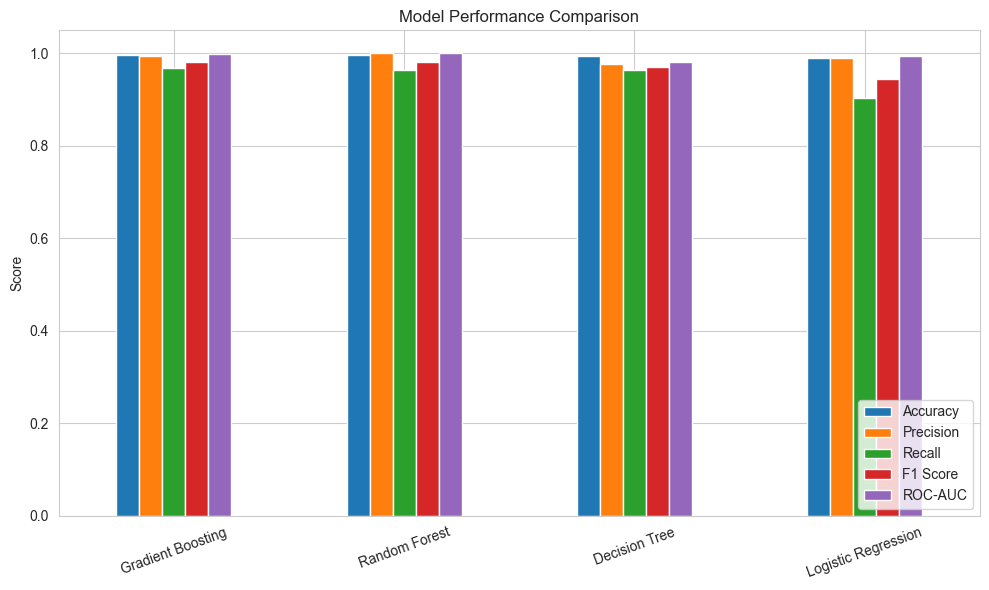

In [ ]:
summary.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

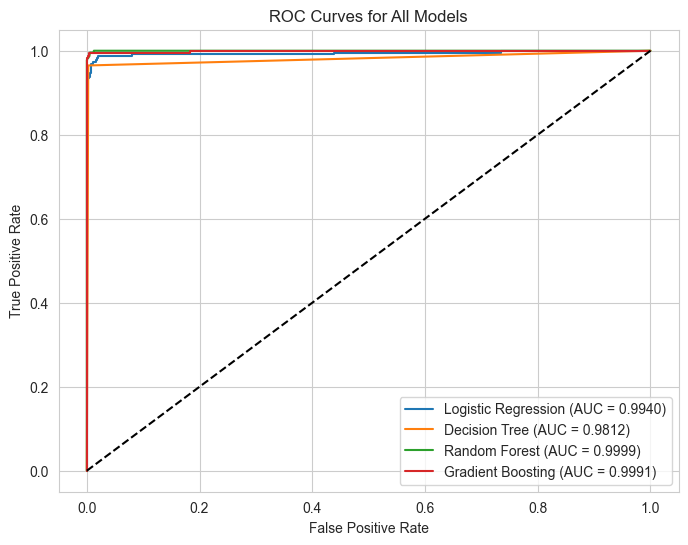

In [ ]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_pred_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.show()

In [ ]:
best_model_name = summary.index[0]
best_model = models[best_model_name]
best_results = results[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"F1 Score  : {best_results['f1']:.4f}")
print(f"Recall    : {best_results['recall']:.4f}")
print(f"Precision : {best_results['precision']:.4f}")

Best Model: Gradient Boosting
F1 Score  : 0.9822
Recall    : 0.9693
Precision : 0.9955


In [ ]:
print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, best_results["y_pred"], target_names=["Legitimate", "Fraud"]))

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      2001
       Fraud       1.00      0.97      0.98       228

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229



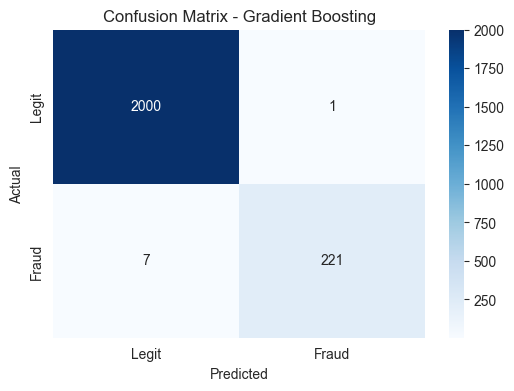

Confusion matrix counts:
True Negatives  (correctly predicted legit):  2000
False Positives (legit but predicted fraud):  1
False Negatives (fraud but predicted legit):  7
True Positives  (correctly predicted fraud):  221


In [ ]:
cm = confusion_matrix(y_test, best_results["y_pred"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion matrix counts:")
print("True Negatives  (correctly predicted legit): ", cm[0][0])
print("False Positives (legit but predicted fraud): ", cm[0][1])
print("False Negatives (fraud but predicted legit): ", cm[1][0])
print("True Positives  (correctly predicted fraud): ", cm[1][1])

## 10. Financial Impact Analysis

Assumptions:
- Average fraud transaction amount = mean amount of fraud transactions in the test set.
- Average legitimate transaction amount = mean amount of legitimate transactions in the test set.
- Cost of a false positive = 5% of the legitimate transaction amount.
- Benefit of a true positive = 100% of the fraud amount.


In [ ]:
test_full = X_test.copy()
test_full["isFraud"] = y_test
test_full["predicted"] = best_results["y_pred"]

# I assumed a 5% cost for blocking genuine customers and counted the full fraud amount as saved.
avg_fraud_amount = test_full.loc[test_full["isFraud"] == 1, "amount"].mean()
avg_legit_amount = test_full.loc[test_full["isFraud"] == 0, "amount"].mean()

print(f"Average fraud transaction amount: ${avg_fraud_amount:,.2f}")
print(f"Average legit transaction amount : ${avg_legit_amount:,.2f}")

Average fraud transaction amount: $1,034,414.59
Average legit transaction amount : $102,694.19


In [ ]:
tn, fp, fn, tp = cm.ravel()
money_saved = tp * avg_fraud_amount
money_lost_to_fraud = fn * avg_fraud_amount
cost_of_false_positives = fp * avg_legit_amount * 0.05
net_benefit = money_saved - cost_of_false_positives

print("Financial Impact on the Test Set:")
print(f"  Money saved by catching fraud  : ${money_saved:,.2f}")
print(f"  Money lost to missed fraud    : ${money_lost_to_fraud:,.2f}")
print(f"  Cost of false positives       : ${cost_of_false_positives:,.2f}")
print(f"  NET BENEFIT                   : ${net_benefit:,.2f}")

Financial Impact on the Test Set:
  Money saved by catching fraud  : $228,605,624.24
  Money lost to missed fraud    : $7,240,902.13
  Cost of false positives       : $5,134.71
  NET BENEFIT                   : $228,600,489.54


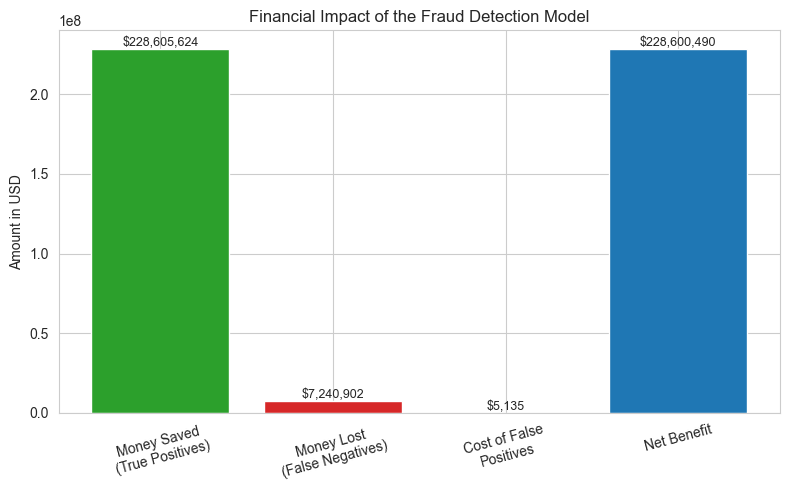

In [ ]:
labels = ["Money Saved\n(True Positives)", "Money Lost\n(False Negatives)", "Cost of False\nPositives", "Net Benefit"]
values = [money_saved, money_lost_to_fraud, cost_of_false_positives, net_benefit]
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#1f77b4"]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors)
plt.title("Financial Impact of the Fraud Detection Model")
plt.ylabel("Amount in USD")
plt.xticks(rotation=15)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"${val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

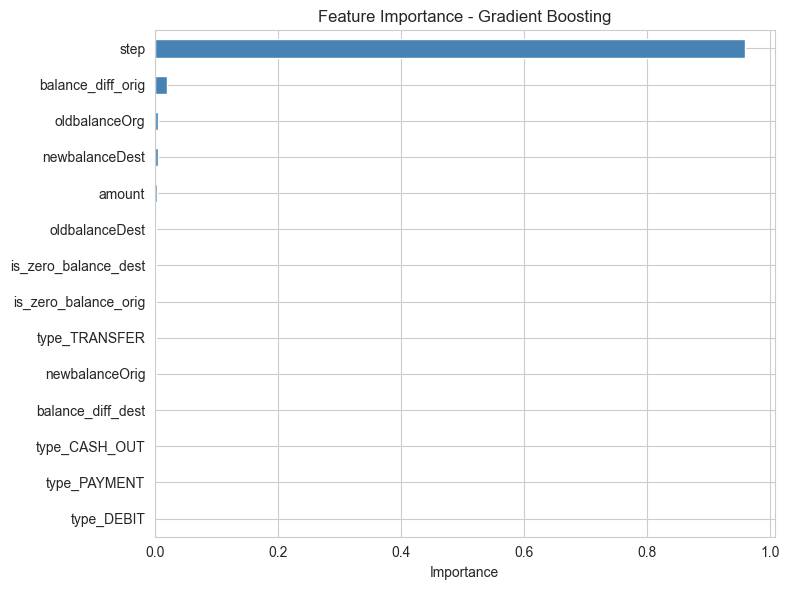

In [29]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(8, 6))
    feat_imp.plot(kind="barh", color="steelblue")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("This model does not have feature_importances_, skipping plot.")


## 11. Saving the Model

The trained model, scaler, and column list are saved as `.joblib` files for reuse by the Streamlit app.


In [ ]:
# I saved the model, scaler, and column list so the Streamlit app can reuse them without retraining.
joblib.dump(best_model, "fraud_detection_model.joblib")
print("Model saved as fraud_detection_model.joblib")

joblib.dump(scaler, "scaler.joblib")
print("Scaler saved as scaler.joblib")

joblib.dump(list(X.columns), "model_columns.joblib")
print("Model columns saved as model_columns.joblib")

Model saved as fraud_detection_model.joblib
Scaler saved as scaler.joblib
Model columns saved as model_columns.joblib


In [ ]:
loaded_model = joblib.load("fraud_detection_model.joblib")
loaded_scaler = joblib.load("scaler.joblib")

sample = X_test.iloc[:5]
sample_scaled = loaded_scaler.transform(sample)
sample_pred = loaded_model.predict(sample_scaled)

print("Test predictions on 5 sample transactions:")
for i, p in enumerate(sample_pred):
    print(f"  Transaction {i+1}: predicted isFraud = {p}")
print("\nModel loads and predicts successfully!")

Test predictions on 5 sample transactions:
  Transaction 1: predicted isFraud = 0
  Transaction 2: predicted isFraud = 0
  Transaction 3: predicted isFraud = 0
  Transaction 4: predicted isFraud = 0
  Transaction 5: predicted isFraud = 0

Model loads and predicts successfully!
